:::{admonition} Do this exercise yourself!
:class: important

This notebook is an exercise for practicing using plenoptic. You should work through it on your own, either by clicking on one of the following buttons or opening up a new notebook on your own machine and following along.

Regardless of which you choose, you should keep this page open for reference, as the links to other pages in the documentation (and some images) are broken in the downloaded and binder notebooks.

If you would like to install everything required to run this notebooks on your local machine, run `pip install plenoptic[nb]`. See [](install-doc) and [](jupyter-doc) for more details.

Download the executed notebook: **{nb-download}`3_textures.ipynb`**!

Run it in your browser: **{binder}`3_textures.ipynb`**!

:::

# Texture synthesis

See [](ps-index) page for more details on using the {class}`~plenoptic.models.PortillaSimoncelli` model.

:::{attention}
It is recommended that you first work through the [](simple-metamer) exercise before this one! The optimization procedure here is a bit more complex.
:::

In [1]:
# needed for the plotting/animating:
import matplotlib.pyplot as plt
import torch

import plenoptic as po

plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]
# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The texture model requires a little more configuring to find reliably good metamers. In the [original paper](https://www.cns.nyu.edu/pub/eero/portilla99-reprint.pdf), the authors use coarse-to-fine synthesis, which starts with coarsest scales (i.e., lowest spatial frequencies) of the model representation and moves to finer and finer scales. In plenoptic, we have found that this is unnecessary for finding good metamers (though it is possible, using {class}`~plenoptic.MetamerCTF`; see example at that link), as long as one uses the {class}`torch.optim.LBFGS` optimizer and a custom loss function, {func}`plenoptic.loss.portilla_simoncelli_loss_factory`. (See [this issue](https://github.com/plenoptic-org/plenoptic/issues/365) if you are interested in how we came to this suggestion.)

The following block synthesizes a texture metamer using our suggested setup:

In [2]:
img = po.data.reptile_skin().to(DEVICE)
ps = po.models.PortillaSimoncelli(img.shape[-2:])
ps.to(DEVICE)
loss = po.loss.portilla_simoncelli_loss_factory(ps, img)
met = po.Metamer(
    img,
    ps,
    loss_function=loss,
)
opt_kwargs = {
    "max_iter": 10,
    "max_eval": 10,
    "history_size": 100,
    "line_search_fn": "strong_wolfe",
    "lr": 1,
}
met.setup(optimizer=torch.optim.LBFGS, optimizer_kwargs=opt_kwargs)
met.synthesize(max_iter=100, store_progress=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Visualize what synthesis looks like:

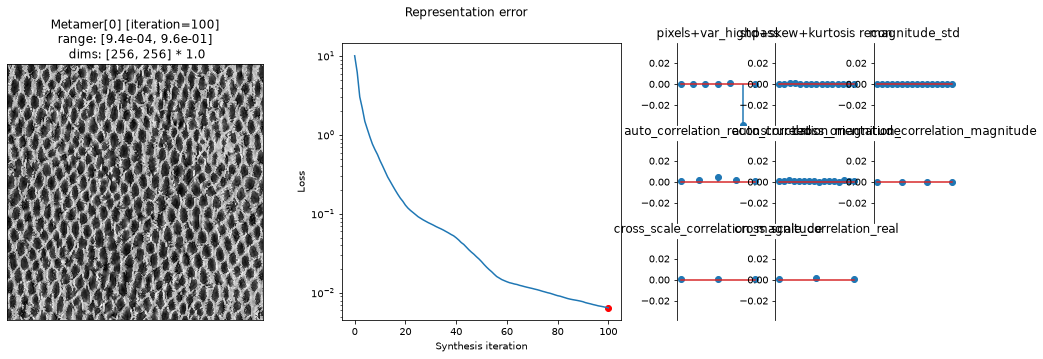

In [3]:
po.plot.synthesis_status(met);

And let's view that synthesis over time:

In [4]:
met.to("cpu")
po.plot.synthesis_animate(met)

## Different target image

As we [practiced earlier](simple-metamer-diff-target), we can change the target image for metamer synthesis straightforwardly. What does it look like to use a different texture? A non-texture image? Are any of these results surprising?

:::{admonition} More texture images
:class: hint

If you run the following lines, you can download some additional texture images used in the original Portilla and Simoncelli paper for use with the model.

:::

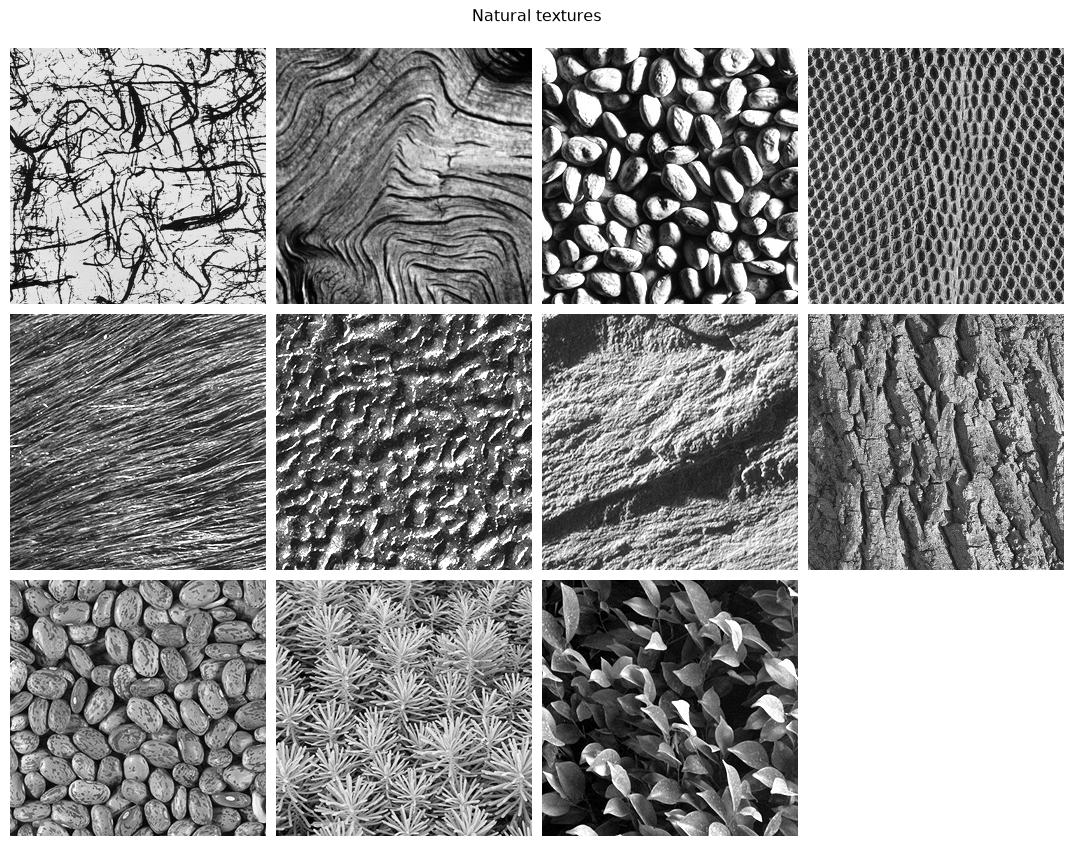

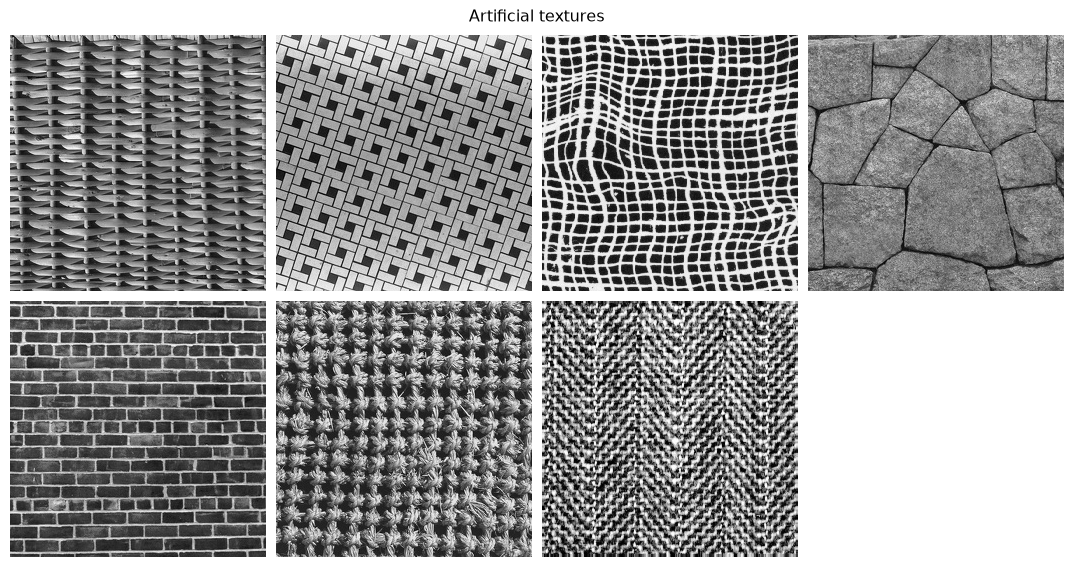

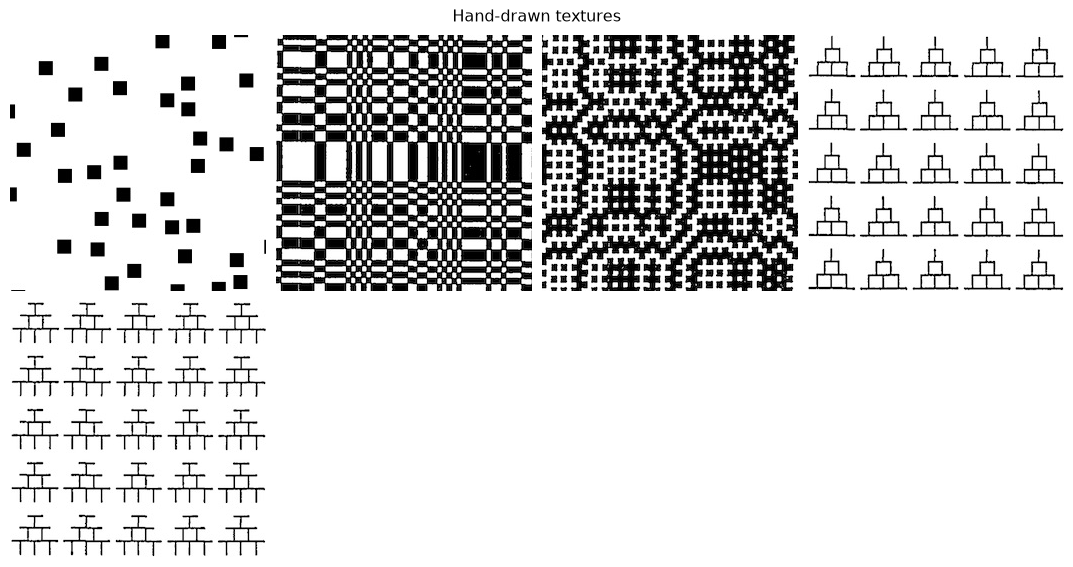

In [5]:
texture_path = po.data.fetch_data("portilla_simoncelli_images.tar.gz")

natural = [
    "3a",
    "6a",
    "8a",
    "14b",
    "15c",
    "15d",
    "15e",
    "15f",
    "16c",
    "16b",
    "16a",
]
natural = po.load_images([texture_path / f"fig{num}.jpg" for num in natural])
artificial = ["4a", "4b", "14a", "16e", "14e", "14c", "5a"]
artificial = po.load_images([texture_path / f"fig{num}.jpg" for num in artificial])
hand_drawn = ["5b", "13a", "13b", "13c", "13d"]
hand_drawn = po.load_images([texture_path / f"fig{num}.jpg" for num in hand_drawn])

# Why not visualize them as well?
fig = po.plot.imshow(natural, col_wrap=4, title=None)
fig.suptitle("Natural textures", y=1.05)
fig = po.plot.imshow(artificial, col_wrap=4, title=None)
fig.suptitle("Artificial textures", y=1.05)
fig = po.plot.imshow(hand_drawn, col_wrap=4, title=None)
fig.suptitle("Hand-drawn textures", y=1.05);

Now let's try picking a different target image and running synthesis:

In [ ]:
img = ...  # SPECIFY AN IMAGE HERE
met = po.Metamer(
    img,
    ps,
    loss_function=loss,
)
opt_kwargs = {
    "max_iter": 10,
    "max_eval": 10,
    "history_size": 100,
    "line_search_fn": "strong_wolfe",
    "lr": 1,
}
met.setup(optimizer=torch.optim.LBFGS, optimizer_kwargs=opt_kwargs)
met.synthesize(max_iter=100, store_progress=True)

## Different initial image

We also know how to [change the initial image](simple-metamer-diff-initial) and run metamer synthesis. What does it look like if our target is a texture, but our initial image is a face?